**Step 1 :**

Installs the two libraries, pgmpy and daft-pgm, required for the later steps in the project.

In [ ]:
#!pip install networkx==2.2
!pip install pgmpy
!pip install 'daft-pgm'
#!pip install graphviz
#!apt-get install graphviz
#!pip install pygraphviz
#!apt-get install pygraphviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 31.5 MB/s eta 0:00:00


**Step 2:**

Opens the Colab file uploader, loads the chosen file, and imports pandas to read the dataset.

In [ ]:
from google.colab import files

uploaded = files.upload()  # Choose File screen open here

import pandas as pd

# Upload file add
file_name = list(uploaded.keys())[0]
print("Uploaded File Name:", file_name)


Saving lymphography_data.csv to lymphography_data.csv
Uploaded File Name: lymphography_data.csv


**Step 3:**

Reads the first 500 characters of the uploaded file to quickly preview the raw CSV structure before fully loading it.


In [ ]:
# Read the first 500 characters to get a quick preview of the file

with open(file_name, "r", errors="ignore") as f:
    text_preview = f.read(500)

print("===== CSV PREVIEW =====")
print(text_preview)
print("========================")

===== CSV PREVIEW =====
Class,Lymphatics,block of affere,bl. of lymph. c,bl. of lymph. s,by pass,extravasates,regeneration of,early uptake in,lym.nodes dimin,lym.nodes enlar,changes in lym, defect in node, changes in node,changes in stru,special forms,dislocation of,exclusion of no,no. of nodes in
3,4,2,1,1,1,1,1,2,1,2,2,2,4,8,1,1,2,2
2,3,2,1,1,2,2,1,2,1,3,3,2,3,4,2,2,2,2
3,3,2,2,2,2,2,2,2,1,4,3,3,4,8,3,2,2,7
3,3,1,1,1,1,2,1,2,1,3,3,4,4,4,3,1,2,6
2,3,1,1,1,1,1,1,1,1,2,2,4,3,5,1,2,2,1
2,2,1,1,1,1,1,1,2,1,3,3,3,3,6,3,1,2


**Step 4:**

Uploads the file again, reads it properly with pandas, and prints the first rows, column names, and dataset shape to verify that the CSV was loaded correctly.

The file is re-uploaded here because this is the actual point where we load the structured dataset into a dataframe after previewing it in the previous step.

In [ ]:
from google.colab import files
import pandas as pd

uploaded = files.upload()
file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)   # FIRST ROW IS HEADER — DO NOT USE header=None

print("First 5 rows:")
print(df.head())

print("\nColumn names:")
print(list(df.columns))

print("\nDataset shape:")
print(df.shape)

Saving lymphography_data.csv to lymphography_data (1).csv
First 5 rows:
   Class  Lymphatics  block of affere  bl. of lymph. c  bl. of lymph. s  \
0      3           4                2                1                1   
1      2           3                2                1                1   
2      3           3                2                2                2   
3      3           3                1                1                1   
4      2           3                1                1                1   

   by pass  extravasates  regeneration of  early uptake in  lym.nodes dimin  \
0        1             1                1                2                1   
1        2             2                1                2                1   
2        2             2                2                2                1   
3        1             2                1                2                1   
4        1             1                1                1                1   

  

**Step 5:**

Filters the dataset to keep only classes 2 and 3, converts them to binary labels 0 and 1, separates features and target, and prints the dataset shape, class distribution, column names, and first rows to confirm the preprocessing.

In [ ]:
# ============================================
# Filter class 2 and 3, encode labels,
# separate features/target, print all
# ============================================

import pandas as pd

# Filter only class 2 and class 3
df = df[(df["Class"] == 2) | (df["Class"] == 3)]

# Recode: 2 → 0, 3 → 1
df["Class"] = df["Class"].map({2: 0, 3: 1})

# Separate X (features) and y (target)
X = df.drop("Class", axis=1)
y = df["Class"]

# Print info
print("===== FILTERED DATASET SHAPE =====")
print(df.shape)
print("\n==================================\n")

print("===== CLASS DISTRIBUTION =====")
print(df["Class"].value_counts())
print("\n==================================\n")

print("===== COLUMN NAMES (VERTICAL) =====\n")
for col in df.columns:
    print(col)
print("\n====================================\n")

print("===== FIRST 5 ROWS OF PROCESSED DATA =====")
print(df.head().to_string())
print("\n==========================================\n")

===== FILTERED DATASET SHAPE =====
(142, 19)


===== CLASS DISTRIBUTION =====
Class
0    81
1    61
Name: count, dtype: int64


===== COLUMN NAMES (VERTICAL) =====

Class
Lymphatics
block of affere
bl. of lymph. c
bl. of lymph. s
by pass
extravasates
regeneration of
early uptake in
lym.nodes dimin
lym.nodes enlar
changes in lym
 defect in node
 changes in node
changes in stru
special forms
dislocation of
exclusion of no
no. of nodes in


===== FIRST 5 ROWS OF PROCESSED DATA =====
   Class  Lymphatics  block of affere  bl. of lymph. c  bl. of lymph. s  by pass  extravasates  regeneration of  early uptake in  lym.nodes dimin  lym.nodes enlar  changes in lym   defect in node   changes in node  changes in stru  special forms  dislocation of  exclusion of no  no. of nodes in
0      1           4                2                1                1        1             1                1                2                1                2               2                2                 4      

**Step 6:**

Runs a Chi-Square independence test for each feature by creating a contingency table against the target, skipping invalid columns, and printing the p-values to evaluate how strongly each feature is associated with the class.

In [ ]:
# ============================================
# Chi-Square independence test
# ============================================

import scipy.stats as stats
import pandas as pd

print("========== CHI-SQUARE TEST RESULTS ==========\n")

chi_results = {}

for col in X.columns:

    # Skip columns with single unique value (cannot compute Chi-Square)
    if X[col].nunique() < 2:
        print(f"Feature: {col}")
        print("Chi-Square skipped (only one unique value).")
        print("----------------------------------------")
        continue

    # Crosstab (feature vs target)
    contingency_table = pd.crosstab(X[col], y)

    # Skip empty crosstab edge case
    if contingency_table.size == 0:
        print(f"Feature: {col}")
        print("Chi-Square skipped (empty crosstab).")
        print("----------------------------------------")
        continue

    # Perform Chi-Square test
    chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
    chi_results[col] = p

    print(f"Feature: {col}")
    print(f"Chi-Square p-value: {p}")
    print("----------------------------------------")

print("\n=============================================\n")


========== CHI-SQUARE TEST RESULTS ==========

Feature: Lymphatics
Chi-Square p-value: 0.489518742392549
----------------------------------------
Feature: block of affere
Chi-Square p-value: 5.853538229201745e-08
----------------------------------------
Feature: bl. of lymph. c
Chi-Square p-value: 0.08481528464831944
----------------------------------------
Feature: bl. of lymph. s
Chi-Square p-value: 0.7460416841988489
----------------------------------------
Feature: by pass
Chi-Square p-value: 0.1877567379132245
----------------------------------------
Feature: extravasates
Chi-Square p-value: 0.6278539339690115
----------------------------------------
Feature: regeneration of
Chi-Square p-value: 0.10520078984644822
----------------------------------------
Feature: early uptake in
Chi-Square p-value: 1.0674238537457976e-05
----------------------------------------
Feature: lym.nodes dimin
Chi-Square p-value: 1.0
----------------------------------------
Feature: lym.nodes enlar
Chi-Sq

**Step 7:**

Calculates Cramer's V for each feature by building a crosstab with the target, skipping invalid columns, and printing the correlation scores to measure the strength of association between each feature and the class.

In [ ]:
# ============================================
# Cramer's V Correlation Analysis
# ============================================

import numpy as np
import scipy.stats as stats
import pandas as pd

print("========== CRAMER'S V RESULTS ==========\n")

def cramers_v(confusion_matrix):
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(k - 1, r - 1))))

cramer_results = {}

for col in X.columns:

    # Single value columns cannot compute Cramer's V
    if X[col].nunique() < 2:
        print(f"Feature: {col}")
        print("Cramer's V skipped (only one unique value).")
        print("----------------------------------------")
        continue

    cm = pd.crosstab(X[col], y)

    if cm.size == 0:
        print(f"Feature: {col}")
        print("Cramer's V skipped (empty crosstab).")
        print("----------------------------------------")
        continue

    v = cramers_v(cm)
    cramer_results[col] = v

    print(f"Feature: {col}")
    print(f"Cramer's V: {v}")
    print("----------------------------------------")

print("\n========================================\n")

========== CRAMER'S V RESULTS ==========

Feature: Lymphatics
Cramer's V: 0.10030464362985754
----------------------------------------
Feature: block of affere
Cramer's V: 0.45510638287205885
----------------------------------------
Feature: bl. of lymph. c
Cramer's V: 0.1446249472820419
----------------------------------------
Feature: bl. of lymph. s
Cramer's V: 0.0271779873176064
----------------------------------------
Feature: by pass
Cramer's V: 0.11054068887136748
----------------------------------------
Feature: extravasates
Cramer's V: 0.040679287979634486
----------------------------------------
Feature: regeneration of
Cramer's V: 0.13595968218493248
----------------------------------------
Feature: early uptake in
Cramer's V: 0.36949526513257414
----------------------------------------
Feature: lym.nodes dimin
Cramer's V: 0.0
----------------------------------------
Feature: lym.nodes enlar
Cramer's V: 0.42040054468178123
----------------------------------------
Feature: ch

**Step 8:**

Computes Mutual Information scores for all features to measure how much each one contributes to predicting the target, sorts them by importance, and prints the scores and feature ranking.

In [ ]:
# ============================================
# Mutual Information Feature Selection
# ============================================

from sklearn.feature_selection import mutual_info_classif
import pandas as pd

print("========== MUTUAL INFORMATION RESULTS ==========\n")

# Compute MI (all features treated as discrete)
mi_scores = mutual_info_classif(X, y, discrete_features=True)

# Create a sorted Series: feature → MI score
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

# Print scores cleanly, one-by-one
for feature, score in mi_series.items():
    print(f"Feature: {feature}")
    print(f"Mutual Information Score: {score}")
    print("----------------------------------------")

print("\n===============================================\n")

# Selected features (ordered by importance)
selected_features = mi_series.index.tolist()

print("Selected features in order of importance:\n")
for f in selected_features:
    print(f)


========== MUTUAL INFORMATION RESULTS ==========

Feature:  changes in node
Mutual Information Score: 0.2054568868166714
----------------------------------------
Feature: no. of nodes in
Mutual Information Score: 0.16412061549592674
----------------------------------------
Feature: block of affere
Mutual Information Score: 0.1137624041094748
----------------------------------------
Feature: special forms
Mutual Information Score: 0.09874353528374057
----------------------------------------
Feature: lym.nodes enlar
Mutual Information Score: 0.09270708296461741
----------------------------------------
Feature: early uptake in
Mutual Information Score: 0.08262620035741643
----------------------------------------
Feature: changes in stru
Mutual Information Score: 0.07610634142396833
----------------------------------------
Feature:  defect in node
Mutual Information Score: 0.03478806609477325
----------------------------------------
Feature: dislocation of
Mutual Information Score: 0.02880

**Step 9:**

Creates a horizontal bar chart to visually display the Mutual Information scores, showing which features are more important for predicting the target.

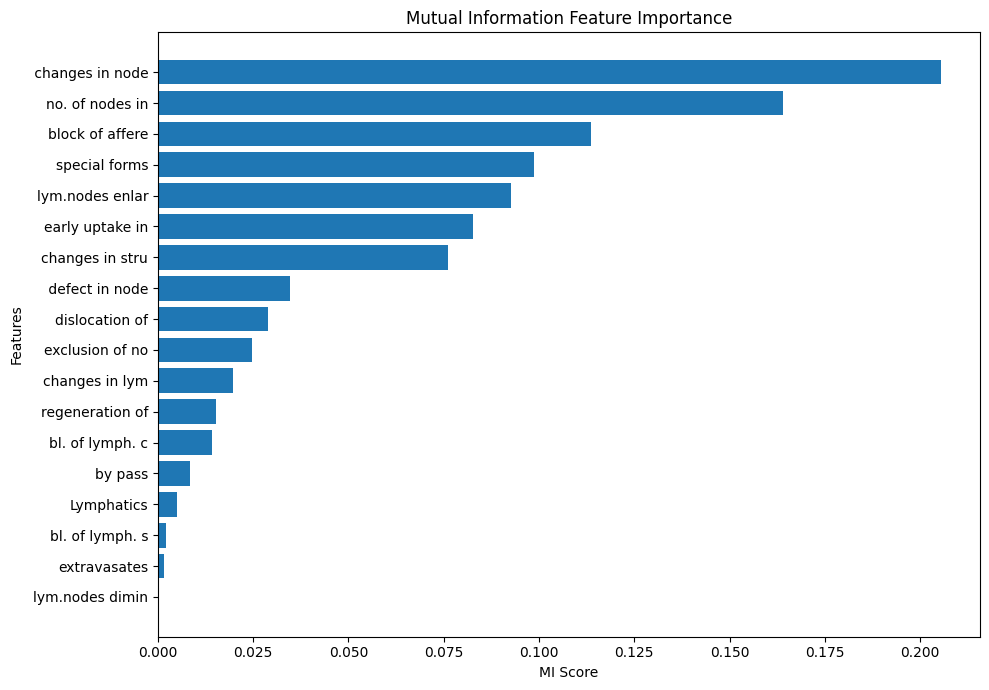

In [ ]:
# ============================================
# FEATURE IMPORTANCE VISUALIZATION (Mutual Information)
# ============================================

import matplotlib.pyplot as plt

mi_series_sorted = mi_series.sort_values(ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(mi_series_sorted.index, mi_series_sorted.values)
plt.title("Mutual Information Feature Importance")
plt.xlabel("MI Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()


**Step 10:**

Selects the features ranked by Mutual Information, applies an 80/20 train-test split with stratification, and prints the shapes and class balances to confirm the dataset is properly divided.

In [ ]:
# ============================================
# Train/Test Split (80% training, 20% test)
# Using selected features from Mutual Information
# ============================================

from sklearn.model_selection import train_test_split

# X: only selected features (Mutual Information list)
X_selected = df[selected_features]

# y: class label
y = df["Class"]

# Perform split
X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Print clean output
print("===== TRAIN/TEST SPLIT COMPLETE =====\n")
print("Training set shape:")
print(X_train.shape)
print("\nTesting set shape:")
print(X_test.shape)
print("\nClass distribution in training set:")
print(y_train.value_counts())
print("\nClass distribution in test set:")
print(y_test.value_counts())
print("\n======================================\n")

===== TRAIN/TEST SPLIT COMPLETE =====

Training set shape:
(113, 18)

Testing set shape:
(29, 18)

Class distribution in training set:
Class
0    64
1    49
Name: count, dtype: int64

Class distribution in test set:
Class
0    17
1    12
Name: count, dtype: int64




**Step 11:**

Builds a binary classification neural network, trains it on the training data, evaluates performance on the test set using accuracy and loss, and then computes detailed metrics such as the confusion matrix and classification report (precision, recall, F1-score) to analyze how well the model distinguishes between the two classes.

In [ ]:
# ============================================
# Neural Network Model
# ============================================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import classification_report, confusion_matrix

# Build the model
model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=8,
    verbose=0  # sessiz eğitim
)

print("===== TRAINING COMPLETE =====\n")

# Evaluate on test set
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"Test Accuracy: {accuracy}")
print(f"Test Loss: {loss}\n")

# Predictions
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Metrics
print("===== CONFUSION MATRIX =====")
print(confusion_matrix(y_test, y_pred))

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


===== TRAINING COMPLETE =====

Test Accuracy: 0.7931034564971924
Test Loss: 0.5251880884170532

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
===== CONFUSION MATRIX =====
[[14  3]
 [ 3  9]]

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.82      0.82      0.82        17
           1       0.75      0.75      0.75        12

    accuracy                           0.79        29
   macro avg       0.79      0.79      0.79        29
weighted avg       0.79      0.79      0.79        29



**Step 12:**

Uses the PC algorithm to learn the structure of a Bayesian Network from the training data, estimates a DAG showing dependencies between variables, and builds a Discrete Bayesian Network model based on the discovered edges.

In [ ]:
# ============================================
# Bayesian Network with PC algorithm
# ============================================

from pgmpy.estimators import PC, BayesianEstimator
from pgmpy.models import DiscreteBayesianNetwork
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

print("===== BAYESIAN NETWORK STRUCTURE LEARNING (PC) =====")

# Combine training data: features + Class
train_data = pd.concat([X_train, y_train], axis=1)

# PC algorithm (constraint-based structure learning)
pc = PC(train_data)

# Learn a DAG structure; valid return_type values: 'dag', 'pdag', 'cpdag', 'skeleton'
dag = pc.estimate(return_type='dag')

# Build BayesianModel from the learned DAG
model_bn = DiscreteBayesianNetwork(dag.edges())

print("Nodes in the learned BN:")
print(model_bn.nodes())
print("\nEdges in the learned BN:")
print(model_bn.edges())

===== BAYESIAN NETWORK STRUCTURE LEARNING (PC) =====


  0%|          | 0/5 [00:00<?, ?it/s]

Nodes in the learned BN:
[' defect in node', ' changes in node', 'special forms', 'Class', 'changes in stru', 'lym.nodes enlar', 'bl. of lymph. c', 'by pass']

Edges in the learned BN:
[(' defect in node', ' changes in node'), ('special forms', 'Class'), ('changes in stru', 'lym.nodes enlar'), ('bl. of lymph. c', 'by pass')]


**Step 13:**

Fits the Bayesian Network by estimating each node's Conditional Probability Distribution (CPD) using the Bayesian Estimator with the BDeu prior, which stands for Bayesian Dirichlet Equivalent Uniform, a smoothing prior that assumes all outcomes are equally likely before seeing the data, helping avoid zero-probability issues.

In [ ]:
# Fit CPDs using Bayesian Estimator
model_bn.fit(train_data, estimator=BayesianEstimator, prior_type="BDeu")

print("\n===== CPDs LEARNED =====")


===== CPDs LEARNED =====


**Step 14:**

Prepares the test data by selecting all Bayesian Network nodes except the target (“Class”), aligns the test features to the network structure, and uses the trained Bayesian Network to predict the class values.

In [ ]:
# Prepare test input for the BN:
# use all model nodes except 'Class' (which we want to predict)

bn_nodes = list(model_bn.nodes())
bn_nodes.remove("Class")                  # we want to infer this

# Align X_test to the BN's feature nodes
X_test_bn = X_test[bn_nodes].copy()

# Predict Class with the Bayesian Network
pred_df_bn = model_bn.predict(X_test_bn)

y_pred_bn = pred_df_bn["Class"]

  0%|          | 0/28 [00:00<?, ?it/s]

**Step 15:**

Prints the Bayesian Network's performance by showing the confusion matrix and the full classification report, including precision, recall, and F1-score, to evaluate how well the PC-based model predicts the test classes.

In [ ]:
print("\n===== BAYESIAN NETWORK RESULTS (PC) =====\n")

print("CONFUSION MATRIX:")
print(confusion_matrix(y_test, y_pred_bn))

print("\nCLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred_bn))


===== BAYESIAN NETWORK RESULTS (PC) =====

CONFUSION MATRIX:
[[8 9]
 [6 6]]

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.57      0.47      0.52        17
           1       0.40      0.50      0.44        12

    accuracy                           0.48        29
   macro avg       0.49      0.49      0.48        29
weighted avg       0.50      0.48      0.49        29



**Step 16:**

Calculates and prints the accuracy for both models (Neural Network and Bayesian Network), shows their full classification reports, and creates a simple comparison table to easily compare model performances.

In [ ]:
# ============================================
# Short Model Comparison
# ============================================

from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# Compute accuracy values
acc_nn = accuracy_score(y_test, y_pred)
acc_bn = accuracy_score(y_test, y_pred_bn)

print("Neural Network Accuracy:", acc_nn)
print("Bayesian Network (PC) Accuracy:", acc_bn)

# Classification reports for class-wise metrics
print("\n===== Neural Network Classification Report =====")
print(classification_report(y_test, y_pred))

print("\n===== Bayesian Network (PC) Classification Report =====")
print(classification_report(y_test, y_pred_bn))

# Create small comparison table
comparison_df = pd.DataFrame({
    'Model': ['Neural Network', 'Bayesian Network (PC)'],
    'Accuracy': [acc_nn, acc_bn]
})

print("\n===== MODEL ACCURACY COMPARISON =====")
print(comparison_df)


Neural Network Accuracy: 0.7931034482758621
Bayesian Network (PC) Accuracy: 0.4827586206896552

===== Neural Network Classification Report =====
              precision    recall  f1-score   support

           0       0.82      0.82      0.82        17
           1       0.75      0.75      0.75        12

    accuracy                           0.79        29
   macro avg       0.79      0.79      0.79        29
weighted avg       0.79      0.79      0.79        29


===== Bayesian Network (PC) Classification Report =====
              precision    recall  f1-score   support

           0       0.57      0.47      0.52        17
           1       0.40      0.50      0.44        12

    accuracy                           0.48        29
   macro avg       0.49      0.49      0.48        29
weighted avg       0.50      0.48      0.49        29


===== MODEL ACCURACY COMPARISON =====
                   Model  Accuracy
0         Neural Network  0.793103
1  Bayesian Network (PC)  0.482759


**Step 17:**

Implements a Genetic Algorithm to select the best subset of features by optimizing a Logistic Regression model's accuracy, evaluates the chosen features on the test set, and prints performance metrics including accuracy, precision, recall, and F1-score.

In [ ]:
# ============================================
# STEP 17: Genetic Algorithm Feature Selection
# ============================================

!pip install pygad

import pygad
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

print("\n===== GENETIC ALGORITHM FEATURE SELECTION =====\n")

# 1) Convert data to numpy
X_train_np = X_train.values
X_test_np = X_test.values
y_train_np = y_train.values
y_test_np = y_test.values

num_features = X_train_np.shape[1]


# 2) Fitness function
def fitness_func(ga_instance, solution, solution_idx):
    selected_idx = np.where(solution == 1)[0]
    if len(selected_idx) == 0:
        return 0

    X_train_sel = X_train_np[:, selected_idx]

    model = LogisticRegression(max_iter=500)
    model.fit(X_train_sel, y_train_np)

    y_pred = model.predict(X_train_sel)
    accuracy = accuracy_score(y_train_np, y_pred)

    return accuracy


# 3) GA configuration
ga = pygad.GA(
    num_generations=30,
    num_parents_mating=10,
    fitness_func=fitness_func,
    sol_per_pop=20,
    num_genes=num_features,
    init_range_low=0,
    init_range_high=2,
    mutation_percent_genes=10,
    gene_type=int,
    parent_selection_type="sss",
    crossover_type="two_points",
    mutation_type="random",
)

# 4) Run GA
ga.run()

# 5) Best solution
solution, solution_fitness, solution_idx = ga.best_solution()

selected_feature_idx = np.where(solution == 1)[0]
selected_feature_names = X_train.columns[selected_feature_idx].tolist()

print("Selected features:", selected_feature_names)
print("Count:", len(selected_feature_names))


# If GA selects nothing, fallback to all features
if len(selected_feature_idx) == 0:
    print("\n⚠️ GA selected 0 features — using ALL features instead.")
    selected_feature_idx = np.arange(num_features)
    selected_feature_names = X_train.columns.tolist()


# 6) Train Logistic Regression with GA-selected features
X_train_ga = X_train_np[:, selected_feature_idx]
X_test_ga = X_test_np[:, selected_feature_idx]

model_lr = LogisticRegression(max_iter=500)
model_lr.fit(X_train_ga, y_train_np)

# 7) Predict using GA-selected model
y_pred_ga = model_lr.predict(X_test_ga)

# 8) Metrics
acc_ga = accuracy_score(y_test_np, y_pred_ga)
precision_ga, recall_ga, f1_ga, support_ga = precision_recall_fscore_support(
    y_test_np, y_pred_ga, average=None
)

print("\n===== GA MODEL PERFORMANCE =====")
print("Test Accuracy:", acc_ga)
print("\nPrecision:", precision_ga)
print("Recall:", recall_ga)
print("F1-score:", f1_ga)
print("Support:", support_ga)



===== GENETIC ALGORITHM FEATURE SELECTION =====

Selected features: ['no. of nodes in', 'block of affere', 'special forms', 'lym.nodes enlar', 'early uptake in', 'changes in stru', 'dislocation of', 'exclusion of no', 'changes in lym', 'by pass', 'Lymphatics']
Count: 11

===== GA MODEL PERFORMANCE =====
Test Accuracy: 0.7241379310344828

Precision: [0.8        0.64285714]
Recall: [0.70588235 0.75      ]
F1-score: [0.75       0.69230769]
Support: [17 12]


**Step 18:**

Prints the accuracy values of all three models—Neural Network, Bayesian Network, and the Genetic Algorithm model—to make their overall performance easy to compare.

In [ ]:
print("===== MODEL ACCURACY COMPARISON =====\n")

print(f"Neural Network Accuracy:        {acc_nn:.4f}")
print(f"Bayesian Network (PC) Accuracy: {acc_bn:.4f}")
print(f"Genetic Algorithm (GA) Accuracy:{acc_ga:.4f}")


===== MODEL ACCURACY COMPARISON =====

Neural Network Accuracy:        0.7931
Bayesian Network (PC) Accuracy: 0.4828
Genetic Algorithm (GA) Accuracy:0.7586
